In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from utils import load_data, DotDict, eval_models, RandomModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Note: this is mostly just for seeing if the presence of certain keywords might allow more accurate prediction of success.

Turns out you get high precision low recall because models are too pessimistic and keywords are pretty unreliable predictors...

In [10]:
settings = DotDict({
    "undersample": True, # if true, undersample active/acquired classes to match failed for train set
    "include_country": False, # if true, include coountry as a feature
    "filter_tech": True, # if true, only include tech related companies w/ the following keywords
    "only_acquired": False # if true, exclude "active" companies
})

keywords = [
    "AI",
    "Machine Learning",
    "Generative AI",
    "AI Assistant",
    "AI-Enhanced Learning",
    "AI-powered Drug Discovery",
    "AIOps",
    "Artificial Intelligence",
    "ML",
    "NLP",
    "Data Engineering",
    "Data Science",
    "Analytics",
    "Big Data",
    "Computer Vision",
    "Deep Learning",
    # "B2B",
    "Conversational AI",
    "DevOps",
    "Developer Tools"
]

# not the prettiest
dataset, X_train, X_test, y_train, y_test, y_train_orig, train_idx, test_idx, idx_to_class = load_data("updated_data", settings, keywords)


acquired (479, 6) active (3043, 6) failed (733, 6)
final dataset shape (1565, 6)
number of failures in final dataset 183
number of categories after mlb 264


In [11]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
from catboost import CatBoostClassifier



prop_train = sum(y_train==1)/len(y_train)
prop_train_orig = sum(y_train_orig==1)/len(y_train_orig)
prop_test = sum(y_test==1)/len(y_test)
print("original proportion of success in train set", prop_train_orig)
print("proportion of success in train set", prop_train)
print("proportion of success in test set", prop_test)

lr_model = LogisticRegression(class_weight="balanced")
gb_model = GradientBoostingClassifier()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10)
cb_model = CatBoostClassifier(verbose=0)
rndm_model = RandomModel(p=prop_train_orig)

lr_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
cb_model.fit(X_train, y_train)

models = {
    "Logistic Regression": lr_model,
    "Gradient Boosting": gb_model,
    "Random Forest": rf_model,
    "CatBoost": cb_model,
    "Random": rndm_model
}

accs = eval_models(models, X_test, y_test, X_train, y_train, idx_to_class)

original proportion of success in train set 0.8830670926517572
proportion of success in train set 0.5
proportion of success in test set 0.8817891373801917
--- Logistic Regression ---
train f1 score 0.7622377622377622
val f1 score 0.6879271070615034
val precision 0.9263803680981595
val recall 0.5471014492753623
--- Gradient Boosting ---
train f1 score 0.8074074074074075
val f1 score 0.5882352941176471
val precision 0.9090909090909091
val recall 0.43478260869565216
--- Random Forest ---
train f1 score 0.7925925925925926
val f1 score 0.6205250596658711
val precision 0.9090909090909091
val recall 0.47101449275362317
top 10 feature importances for RF
feature: AI, importance: 0.0702968400828056
feature: Fintech, importance: 0.045168202902989084
feature: SaaS, importance: 0.03834780746292494
feature: API, importance: 0.034383031145898524
feature: Enterprise Software, importance: 0.02881887941090922
feature: B2B, importance: 0.026974224780696686
feature: Data Engineering, importance: 0.0228540

unique batch years ['S19' 'S21' 'S24' 'W18' 'S17' 'W22' 'S16' 'W21' 'W23' 'S22' 'S18' 'S23'
 'W19' 'W24' 'S20' 'W16' 'S14' 'W17' 'W14' 'W20' 'W15' 'S15']
total number of datapoints in test set 313


/opt/anaconda3/envs/yc_predict/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/yc_predict/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/yc_predict/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

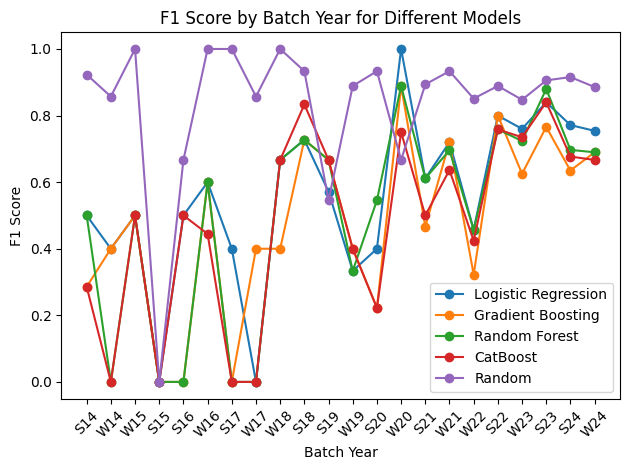

In [9]:
test_dataset = dataset.loc[test_idx]
years = test_dataset["batch"].apply(lambda x: x.split(" ")[0])
unique_years = years.unique()
print("unique batch years", unique_years)
print("total number of datapoints in test set", len(X_test))

f1_scores_by_year = {}
for year in unique_years:
    # print(f"--- Batch Year: {year} ---")
    year_mask = years == year
    year_indices = years[year_mask].index
    
    year_positions = [list(test_idx).index(idx) for idx in year_indices]
    
    X_year = X_test[year_positions]
    y_year = y_test[year_positions]
    
    # print(f"Number of companies in {year}: {len(X_year)}")
    for model in models:
        m = models[model]
        y_pred_year = m.predict(X_year)
        f1 = f1_score(y_year, y_pred_year)
        # print(f"{model} - F1 Score: {f1}")
        if year not in f1_scores_by_year:
            f1_scores_by_year[year] = {}
        f1_scores_by_year[year][model] = f1

import matplotlib.pyplot as plt

for model in models:
    years_sorted = sorted(f1_scores_by_year.keys(), key=lambda x: int(x[1:]))
    f1_scores = [f1_scores_by_year[year][model] for year in years_sorted]
    plt.plot(years_sorted, f1_scores, marker='o', label=model)
plt.xlabel("Batch Year")
plt.ylabel("F1 Score")
plt.title("F1 Score by Batch Year for Different Models")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
    